# Mobile And Laptop Sales Data Analysis

**Assignment:** Exploratory analysis of mobile and laptop sales transactions.  
**Dataset:** `mobile_sales_data.csv`

This notebook uses only results calculated from the supplied dataset.


## Objectives

1. Inspect the data and check its quality.
2. Prepare dates and numeric fields for analysis.
3. Measure sales volume and revenue by product, brand, region, and month.
4. Examine dispatch lead time.
5. Present evidence-based business insights.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [3]:
from google.colab import files

uploaded = files.upload()
csv_name = next(name for name in uploaded if name.lower().endswith(".csv"))

df = pd.read_csv(csv_name)
print(f"Dataset loaded: {csv_name}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Saving sales_data.csv to sales_data (1).csv
Dataset loaded: sales_data (1).csv
Shape: 50,000 rows × 16 columns


## 1. Data inspection


In [4]:
display(df.head())
print(df.dtypes)


,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,NaN,Snapdragon 7 Gen,12GB,128GB,NaN
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,NaN,MediaTek Dimensity,8GB,256GB,NaN
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB


Product                    object
Brand                      object
Product Code               object
Product Specification      object
Price                       int64
Inward Date                object
Dispatch Date              object
Quantity Sold               int64
Customer Name              object
Customer Location          object
Region                     object
Core Specification         object
Processor Specification    object
RAM                        object
ROM                        object
SSD                        object
dtype: object


In [5]:
quality = pd.DataFrame({
    'data_type': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'unique_values': df.nunique()
})
display(quality)
print(f'Duplicate rows: {df.duplicated().sum():,}')


,data_type,missing_values,unique_values
Product,object,0,2
Brand,object,0,20
Product Code,object,0,50000
Product Specification,object,0,50000
Price,int64,0,44112
Inward Date,object,0,731
Dispatch Date,object,0,788
Quantity Sold,int64,0,10
Customer Name,object,0,40013
Customer Location,object,0,25147


Duplicate rows: 0


## 2. Data preparation

The source dataset has already supplied sales quantities and prices. The next cell converts the date and numeric fields, then derives revenue and dispatch lead time.


In [6]:
data = df.copy()
data['Inward Date'] = pd.to_datetime(data['Inward Date'], errors='coerce')
data['Dispatch Date'] = pd.to_datetime(data['Dispatch Date'], errors='coerce')
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')
data['Quantity Sold'] = pd.to_numeric(data['Quantity Sold'], errors='coerce')
data['Revenue'] = data['Price'] * data['Quantity Sold']
data['Dispatch Lead Time (Days)'] = (data['Dispatch Date'] - data['Inward Date']).dt.days
data['Inward Month'] = data['Inward Date'].dt.to_period('M').astype(str)

# Keep valid records for quantitative analysis.
analysis_data = data.dropna(subset=['Price', 'Quantity Sold', 'Inward Date', 'Dispatch Date']).copy()
print(f'Records used for analysis: {len(analysis_data):,}')
print(f'Negative lead times: {(analysis_data['Dispatch Lead Time (Days)'] < 0).sum():,}')


Records used for analysis: 50,000
Negative lead times: 0


## 3. Overall sales summary


In [7]:
summary = pd.DataFrame({
    'Metric': ['Transactions', 'Total units sold', 'Total revenue', 'Average listed price', 'Average dispatch lead time (days)'],
    'Value': [len(analysis_data), analysis_data['Quantity Sold'].sum(), analysis_data['Revenue'].sum(), analysis_data['Price'].mean(), analysis_data['Dispatch Lead Time (Days)'].mean()]
})
display(summary)


,Metric,Value
0,Transactions,"50,000.00"
1,Total units sold,"275,689.00"
2,Total revenue,"28,279,081,122.00"
3,Average listed price,"102,641.41"
4,Average dispatch lead time (days),30.59


## 4. Sales by product and brand


In [8]:
product_summary = (analysis_data.groupby('Product', as_index=False)
    .agg(Orders=('Product Code', 'count'), Units_Sold=('Quantity Sold', 'sum'), Revenue=('Revenue', 'sum'))
    .sort_values('Revenue', ascending=False))
display(product_summary)


,Product,Orders,Units_Sold,Revenue
0,Laptop,25017,138019,14187414822
1,Mobile Phone,24983,137670,14091666300


In [9]:
brand_summary = (analysis_data.groupby('Brand', as_index=False)
    .agg(Orders=('Product Code', 'count'), Units_Sold=('Quantity Sold', 'sum'), Revenue=('Revenue', 'sum'))
    .sort_values('Revenue', ascending=False))
display(brand_summary.head(10))


,Brand,Orders,Units_Sold,Revenue
4,Google,2598,14412,1514617084
10,Nokia,2571,14239,1473167125
1,Apple,2564,14197,1470242666
17,Toshiba,2555,13996,1454585835
16,Sony,2547,14043,1442582351
15,Samsung,2558,14033,1436721278
14,Redmi,2529,13948,1432172989
8,Microsoft,2457,13586,1430065277
9,Motorola,2483,13888,1420578610
0,Acer,2533,13854,1419570397


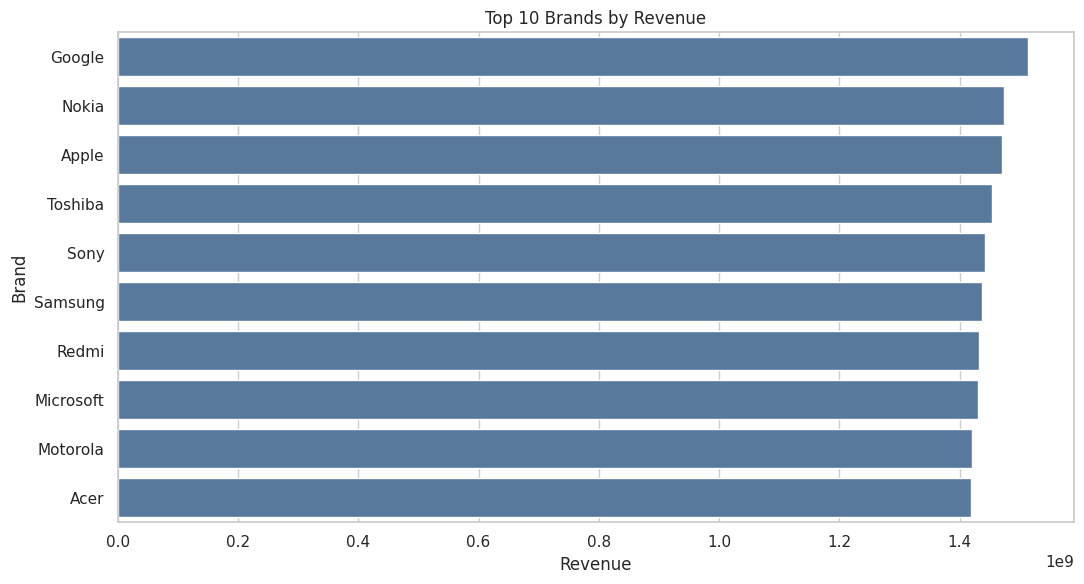

In [10]:
plt.figure(figsize=(11, 6))
sns.barplot(data=brand_summary.head(10), x='Revenue', y='Brand', color='#4C78A8')
plt.title('Top 10 Brands by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()


## 5. Regional performance


In [11]:
region_summary = (analysis_data.groupby('Region', as_index=False)
    .agg(Units_Sold=('Quantity Sold', 'sum'), Revenue=('Revenue', 'sum'))
    .sort_values('Revenue', ascending=False))
display(region_summary)


,Region,Units_Sold,Revenue
4,West,56602,5857063038
3,South,55214,5617869339
2,North,55035,5610214922
0,Central,54093,5601625533
1,East,54745,5592308290


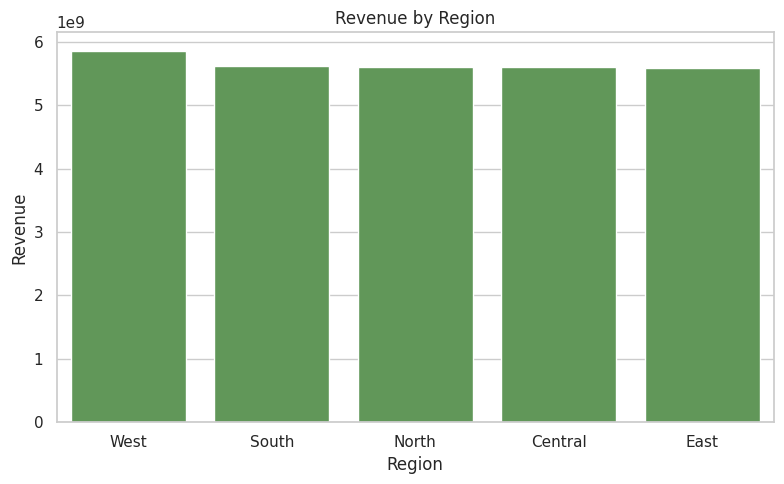

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=region_summary, x='Region', y='Revenue', color='#59A14F')
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


## 6. Monthly revenue trend


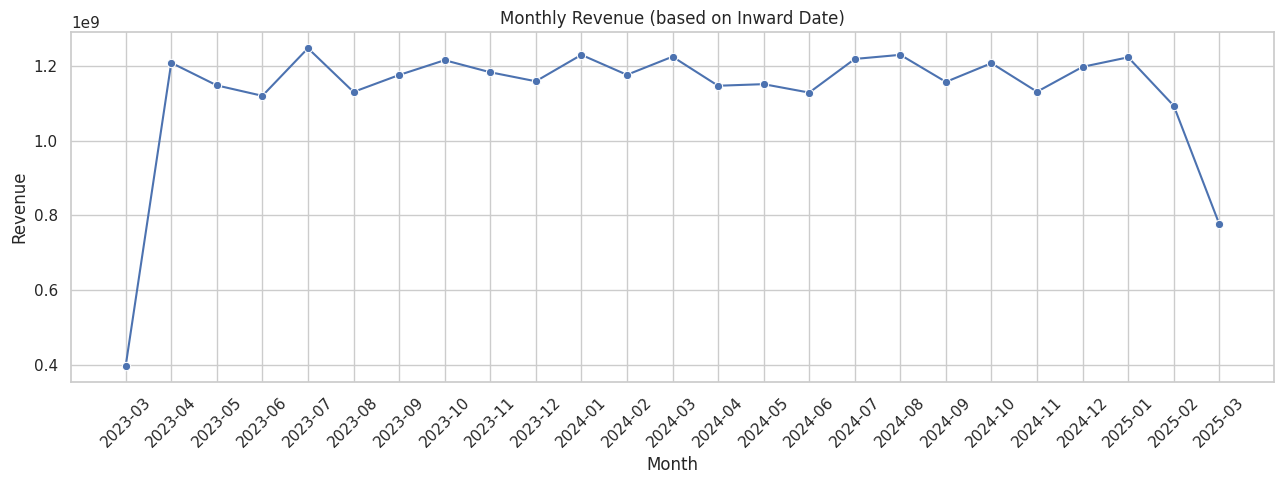

,Inward Month,Revenue
4,2023-07,1247630902
17,2024-08,1229899312
10,2024-01,1229881489
12,2024-03,1224952924
22,2025-01,1223288340


In [13]:
monthly_revenue = (analysis_data.groupby('Inward Month', as_index=False)
    .agg(Revenue=('Revenue', 'sum'))
    .sort_values('Inward Month'))

plt.figure(figsize=(13, 5))
sns.lineplot(data=monthly_revenue, x='Inward Month', y='Revenue', marker='o')
plt.title('Monthly Revenue (based on Inward Date)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly_revenue.sort_values('Revenue', ascending=False).head(5))


## 7. Price, quantity, and dispatch lead time


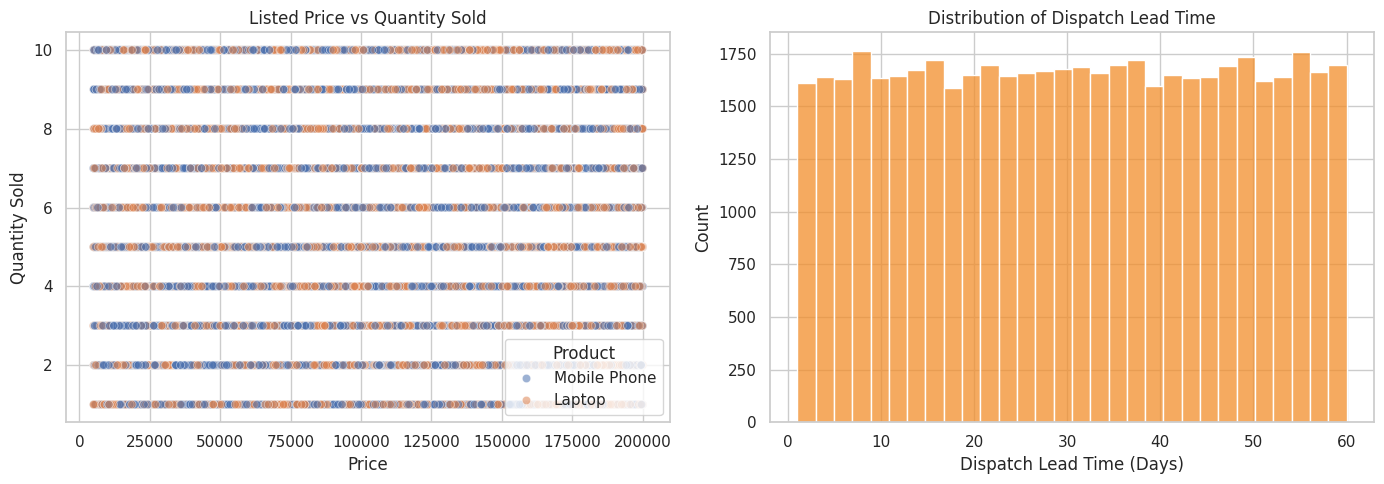

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=analysis_data, x='Price', y='Quantity Sold', hue='Product', alpha=0.55, ax=axes[0])
axes[0].set_title('Listed Price vs Quantity Sold')

sns.histplot(data=analysis_data, x='Dispatch Lead Time (Days)', bins=30, ax=axes[1], color='#F28E2B')
axes[1].set_title('Distribution of Dispatch Lead Time')
plt.tight_layout()
plt.show()


In [15]:
lead_time_summary = analysis_data['Dispatch Lead Time (Days)'].describe()[['min', 'mean', '50%', 'max']]
lead_time_summary.index = ['Minimum', 'Average', 'Median', 'Maximum']
print(lead_time_summary)


Minimum    1.00
Average   30.59
Median    31.00
Maximum   60.00
Name: Dispatch Lead Time (Days), dtype: float64


## 8. Findings and conclusion

- The dataset contains **50,000 transactions** and records **2,75,689 units sold**, generating **₹28,27,90,81,122** in calculated revenue.
- **Laptop** is the product category with the highest calculated revenue (₹14,18,74,14,822).
- **Google** is the leading brand by calculated revenue (₹1,51,46,17,084).
- **West** is the strongest region by calculated revenue (₹5,85,70,63,038).
- The highest-revenue inward month is **2023-07** (₹1,24,76,30,902).
- The average gap between inward and dispatch dates is **30.59 days**.

These results are descriptive: they summarize the supplied transactions and do not establish causation.


## 9. Export prepared data


In [16]:
analysis_data.to_csv('mobile_sales_cleaned.csv', index=False)
print('Prepared dataset saved as mobile_sales_cleaned.csv')


Prepared dataset saved as mobile_sales_cleaned.csv
